# Tutorial 04 — Huấn Luyện & Đánh Giá SVM và Random Forest

> **Mục tiêu:** Huấn luyện SVM + RF trên đặc trưng rung, đánh giá bằng accuracy, confusion matrix, ROC-AUC.
> **Quan trọng:** Chia dữ liệu theo FILE (GroupShuffleSplit) để tránh rò rỉ.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize

from src.config import *

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style("whitegrid")
print("✅ Import thành công.")

✅ Import thành công.


## 1. Load Features

In [2]:
df = pd.read_csv('../notebooks/features_all.csv')
feat_cols = [c for c in df.columns if c not in ['label', 'file_id']]
X = df[feat_cols].values
y_raw = df['label'].values
file_ids = df['file_id'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = list(le.classes_)
print(f"Features: {len(feat_cols)}, Samples: {len(X)}, Classes: {class_names}")

Features: 22, Samples: 22594, Classes: ['B', 'IR', 'Normal', 'OR']


## 2. Chia Dữ Liệu Theo FILE — Tránh Rò Rỉ

### ⚠️ Tại Sao Phải Chia Theo File, Không Theo Segment?

Với overlap 50%, hai segment liền kề **dùng chung 1024 mẫu tín hiệu gốc**. Nếu split ngẫu nhiên, segment 5 (train) và segment 6 (test) chia sẻ dữ liệu → mô hình "nhớ" tín hiệu, không học pattern vật lý.

**Giải pháp:** `GroupShuffleSplit` đảm bảo MỌI segment trong test đến từ file khác hoàn toàn so với train.

In [3]:
# 3-way split: ~50% train / ~20% val / ~30% test (theo file)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss1.split(X, y, groups=file_ids))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.286, random_state=RANDOM_STATE)
train_idx_rel, val_idx_rel = next(gss2.split(
    X[train_val_idx], y[train_val_idx], groups=file_ids[train_val_idx]))

train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# DataFrames gốc (chưa scaled) cho SHAP display
X_train_df = pd.DataFrame(X_train, columns=feat_cols)
X_val_df = pd.DataFrame(X_val, columns=feat_cols)
X_test_df = pd.DataFrame(X_test, columns=feat_cols)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nFiles in train: {len(np.unique(file_ids[train_idx]))}")
print(f"Files in test:  {len(np.unique(file_ids[test_idx]))}")
# Kiểm tra không rò rỉ
overlap_files = set(file_ids[train_idx]) & set(file_ids[test_idx])
print(f"Files trùng train/test: {len(overlap_files)} (phải = 0)")

Train: 11324 (50%)
Val:   5100 (23%)
Test:  6170 (27%)

Files in train: 27
Files in test:  17
Files trùng train/test: 0 (phải = 0)


## 3. Huấn Luyện SVM

In [4]:
pipe_svm = Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=RANDOM_STATE))])
param_svm = {'svm__C': [1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.1], 'svm__kernel': ['rbf']}

t0 = time.time()
gs_svm = GridSearchCV(pipe_svm, param_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
gs_svm.fit(X_train, y_train)
svm_time = time.time() - t0

best_svm = gs_svm.best_estimator_
y_val_pred_svm = best_svm.predict(X_val)
y_test_pred_svm = best_svm.predict(X_test)

print(f"\n{'='*50}")
print(f"SVM — Tham số tốt nhất: {gs_svm.best_params_}")
print(f"Thời gian: {svm_time:.1f}s")
print(f"Val  Accuracy: {accuracy_score(y_val, y_val_pred_svm):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}")
print(f"\n{classification_report(y_test, y_test_pred_svm, target_names=class_names)}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits

SVM — Tham số tốt nhất: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Thời gian: 49.4s
Val  Accuracy: 0.8006
Test Accuracy: 0.8253

              precision    recall  f1-score   support

           B       0.74      0.67      0.70      1186
          IR       0.87      0.77      0.82      2372
      Normal       1.00      1.00      1.00       237
          OR       0.81      0.94      0.87      2375

    accuracy                           0.83      6170
   macro avg       0.85      0.84      0.85      6170
weighted avg       0.83      0.83      0.82      6170



## 4. Huấn Luyện Random Forest

In [5]:
pipe_rf = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
param_rf = {'rf__n_estimators': [100, 200], 'rf__max_depth': [None, 15], 'rf__max_features': ['sqrt', 'log2']}

t0 = time.time()
gs_rf = GridSearchCV(pipe_rf, param_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
rf_time = time.time() - t0

best_rf = gs_rf.best_estimator_
y_val_pred_rf = best_rf.predict(X_val)
y_test_pred_rf = best_rf.predict(X_test)

print(f"\n{'='*50}")
print(f"RF — Tham số tốt nhất: {gs_rf.best_params_}")
print(f"Thời gian: {rf_time:.1f}s")
print(f"Val  Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"\n{classification_report(y_test, y_test_pred_rf, target_names=class_names)}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

RF — Tham số tốt nhất: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
Thời gian: 24.2s
Val  Accuracy: 0.8037
Test Accuracy: 0.8559

              precision    recall  f1-score   support

           B       0.75      0.78      0.77      1186
          IR       0.90      0.79      0.84      2372
      Normal       1.00      0.97      0.99       237
          OR       0.86      0.95      0.90      2375

    accuracy                           0.86      6170
   macro avg       0.88      0.87      0.87      6170
weighted avg       0.86      0.86      0.85      6170



## 5. Confusion Matrix

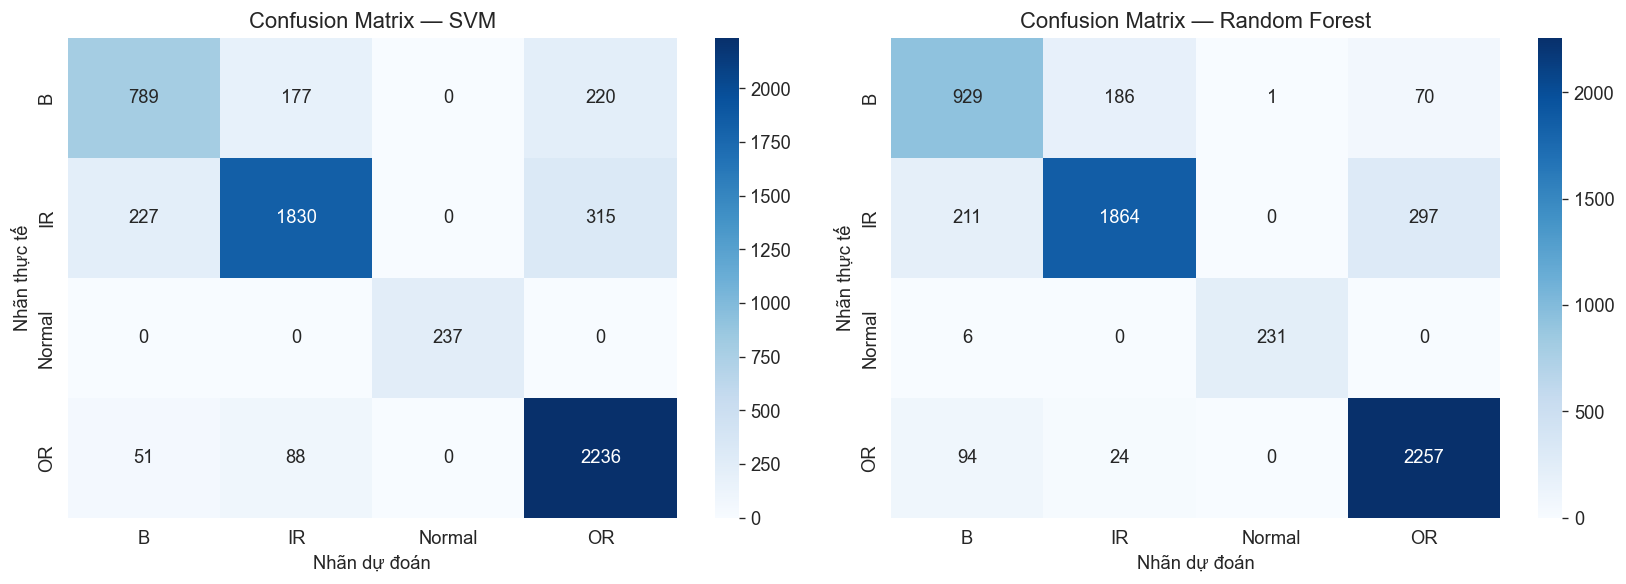

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in [(axes[0], y_test_pred_svm, 'SVM'), (axes[1], y_test_pred_rf, 'Random Forest')]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Nhãn dự đoán')
    ax.set_ylabel('Nhãn thực tế')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.savefig('../figures/confusion_matrix_svm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔎 Đọc Confusion Matrix Như Kỹ Sư

- **Ô chéo chính:** Số mẫu dự đoán ĐÚNG — muốn càng cao càng tốt.
- **Nhầm Normal → IR:** Cảnh báo giả (false alarm) → kỹ sư kiểm tra vô ích.
- **Nhầm IR → Normal:** Bỏ sót lỗi thực (missed detection) → **nguy hiểm hơn nhiều**.

Nếu confusion giữa hai lớp cao → cần thêm feature envelope để phân biệt.

## 6. ROC-AUC Multiclass

In [7]:
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

for name, model in [('SVM', best_svm), ('RF', best_rf)]:
    y_prob = model.predict_proba(X_test)
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
    print(f"{name} ROC-AUC (weighted OvR): {auc:.4f}")

SVM ROC-AUC (weighted OvR): 0.9115
RF ROC-AUC (weighted OvR): 0.9584


In [8]:
# Lưu model và data cho Tutorial 05
import pickle
pickle.dump({
    'best_rf': best_rf, 'best_svm': best_svm,
    'X_test': X_test, 'X_test_df': X_test_df,
    'y_test': y_test, 'class_names': class_names,
    'feat_cols': feat_cols, 'le': le
}, open('../notebooks/models_data.pkl', 'wb'))
print("✅ Đã lưu models_data.pkl cho Tutorial 05")

✅ Đã lưu models_data.pkl cho Tutorial 05


## ⚠️ Giới Hạn Mô Hình — Đọc Kỹ Trước Khi Áp Dụng Tại Nhà Máy

Accuracy cao trên CWRU vì: máy thử nghiệm cố định, lỗi nhân tạo EDM "sạch", không noise công nghiệp.

**Thực tế nhà máy khác hoàn toàn:** lỗi mòn tự nhiên, tải thay đổi, nhiễu máy lân cận.

**Quy trình đúng:**
1. Thu thập dữ liệu từ MÁY ĐÓ khi bình thường (baseline 2-4 tuần)
2. Huấn luyện lại mô hình trên dữ liệu máy thực
3. Bắt đầu với ngưỡng thủ công (RMS, kurtosis) → dùng ML như lớp xác nhận thứ 2

> **Accuracy 99% trên CWRU ≠ accuracy 99% trên máy nhà máy bạn.**

---
*Tutorial 04 hoàn tất. Tiếp theo: Tutorial 05 — SHAP Explanation.*